In [10]:
# ══════════════════════════════════════════════════════════════
# CELL 1 — Install dependencies (run this first, once only)
# ══════════════════════════════════════════════════════════════
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
                       "scikit-learn", "seaborn", "matplotlib", "Pillow", "-q"])
print("✅ Dependencies ready")

✅ Dependencies ready


In [11]:
# ══════════════════════════════════════════════════════════════
# CELL 2 — All imports
# ══════════════════════════════════════════════════════════════
import torch
import torch.nn as nn
import torch.optim as optim
import time
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image

print(f"✅ PyTorch version : {torch.__version__}")
print(f"✅ GPU available   : {torch.cuda.is_available()}")

✅ PyTorch version : 2.10.0+cpu
✅ GPU available   : False


In [12]:
# ══════════════════════════════════════════════════════════════
# CELL 3 — Configuration  ← EDIT THIS CELL ONLY
# ══════════════════════════════════════════════════════════════
TRAIN_DIR  = r"C:\Users\ACER\Desktop\rice_datasets\train"
VAL_DIR    = r"C:\Users\ACER\Desktop\rice_datasets\val"
TEST_DIR   = r"C:\Users\ACER\Desktop\rice_datasets\test"
MODEL_SAVE = "resnet18_rice.pth"

IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

✅ Using device: cpu


In [13]:
# ══════════════════════════════════════════════════════════════
# CELL 4 — Transforms & Datasets
# ══════════════════════════════════════════════════════════════
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(root=VAL_DIR,   transform=val_test_transforms)
#test_dataset  = datasets.ImageFolder(root=TEST_DIR,  transform=val_test_transforms)

CLASS_NAMES  = train_dataset.classes
NUM_CLASSES  = len(CLASS_NAMES)

print(f"✅ Classes        : {CLASS_NAMES}")
print(f"✅ Train samples  : {len(train_dataset)}")
print(f"✅ Val samples    : {len(val_dataset)}")
#print(f"✅ Test samples   : {len(test_dataset)}")

✅ Classes        : ['ClassA-Drought', 'ClassB-PestInfestation', 'ClassC-Healthy']
✅ Train samples  : 1773
✅ Val samples    : 1773


In [14]:
# ══════════════════════════════════════════════════════════════
# CELL 5 — DataLoaders
# ══════════════════════════════════════════════════════════════
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
#test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# Quick sanity check
images, labels = next(iter(train_loader))
print(f"✅ Batch image shape : {images.shape}")  # [32, 3, 224, 224]
print(f"✅ Batch label shape : {labels.shape}")  # [32]

✅ Batch image shape : torch.Size([32, 3, 224, 224])
✅ Batch label shape : torch.Size([32])


In [15]:
# ══════════════════════════════════════════════════════════════
# CELL 6 — Build Model
# ══════════════════════════════════════════════════════════════
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all base layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer to match our number of classes
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model    = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print(f"✅ Model ready — output classes: {NUM_CLASSES} → {CLASS_NAMES}")

✅ Model ready — output classes: 3 → ['ClassA-Drought', 'ClassB-PestInfestation', 'ClassC-Healthy']


In [16]:
# ══════════════════════════════════════════════════════════════
# CELL 7 — Training Loop
# ══════════════════════════════════════════════════════════════
for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print("-" * 30)
    start_time = time.time()

    # ── TRAIN ──
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train   = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * inputs.size(0)
        _, predicted  = torch.max(outputs, 1)
        total_train  += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_train_loss / len(train_dataset)
    epoch_train_acc  = correct_train / total_train

    # ── VALIDATE ──
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val   = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val   += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc  = correct_val / total_val

    elapsed = time.time() - start_time
    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
    print(f"Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.4f}")
    print(f"Time: {elapsed:.2f}s\n")

print("✅ Training complete!")

Epoch 1/10
------------------------------
Train Loss: 0.5403 | Train Acc: 0.7902
Val Loss:   0.2902 | Val Acc:   0.9103
Time: 905.44s

Epoch 2/10
------------------------------
Train Loss: 0.2551 | Train Acc: 0.9239
Val Loss:   0.2401 | Val Acc:   0.8973
Time: 969.69s

Epoch 3/10
------------------------------
Train Loss: 0.1957 | Train Acc: 0.9413
Val Loss:   0.1914 | Val Acc:   0.9323
Time: 961.87s

Epoch 4/10
------------------------------
Train Loss: 0.1705 | Train Acc: 0.9481
Val Loss:   0.1512 | Val Acc:   0.9470
Time: 953.59s

Epoch 5/10
------------------------------
Train Loss: 0.1538 | Train Acc: 0.9532
Val Loss:   0.1326 | Val Acc:   0.9605
Time: 907.29s

Epoch 6/10
------------------------------
Train Loss: 0.1376 | Train Acc: 0.9566
Val Loss:   0.1490 | Val Acc:   0.9442
Time: 964.92s

Epoch 7/10
------------------------------
Train Loss: 0.1365 | Train Acc: 0.9571
Val Loss:   0.0951 | Val Acc:   0.9757
Time: 758.00s

Epoch 8/10
------------------------------
Train Loss: 0

In [17]:
# ══════════════════════════════════════════════════════════════
# CELL 8 — Save Model
# ══════════════════════════════════════════════════════════════
torch.save({
    "model_state_dict"    : model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "class_names"         : CLASS_NAMES,
    "num_classes"         : NUM_CLASSES,
}, MODEL_SAVE)

print(f"✅ Model saved → {MODEL_SAVE}")

✅ Model saved → resnet18_rice.pth


✅ Accuracy: 96.84%

                        precision    recall  f1-score   support

        ClassA-Drought       1.00      1.00      1.00       773
ClassB-PestInfestation       0.93      0.96      0.95       500
        ClassC-Healthy       0.96      0.92      0.94       500

              accuracy                           0.97      1773
             macro avg       0.96      0.96      0.96      1773
          weighted avg       0.97      0.97      0.97      1773



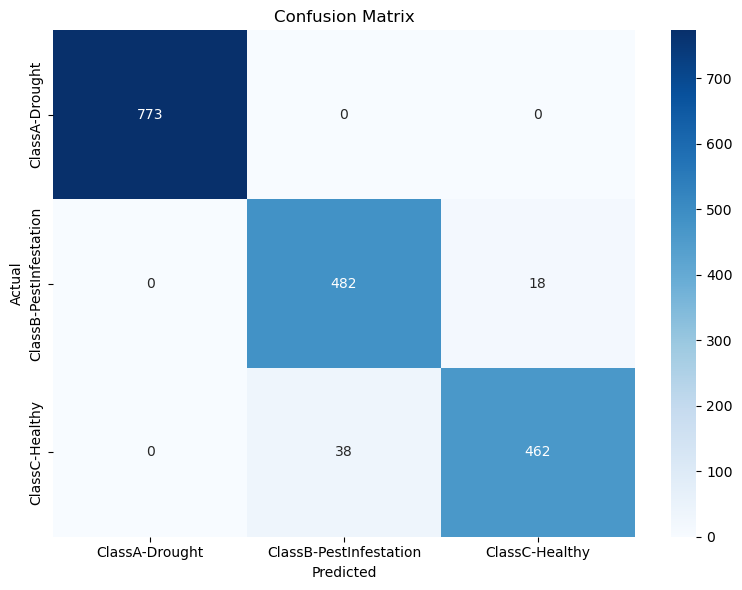

In [18]:
# ══════════════════════════════════════════════════════════════
# CELL 9 — Test Set Evaluation + Confusion Matrix
# ══════════════════════════════════════════════════════════════
all_preds  = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:   # ← uses val_loader instead
        inputs, labels = inputs.to(device), labels.to(device)
        outputs        = model(inputs)
        _, predicted   = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"✅ Accuracy: {test_acc*100:.2f}%\n")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

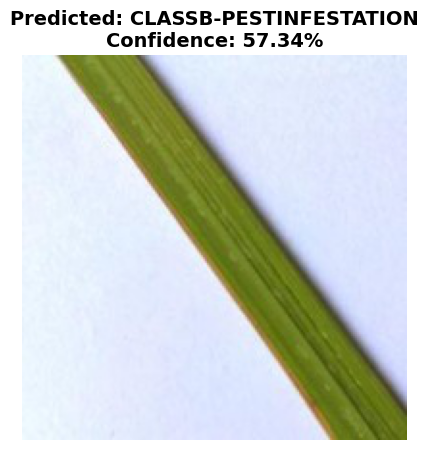


📊 All Probabilities:
  ClassA-Drought        0.61%  
  ClassB-PestInfestation 57.34%  █████████████████
  ClassC-Healthy       42.05%  ████████████


('ClassB-PestInfestation', 0.5733515620231628)

In [25]:
# ══════════════════════════════════════════════════════════════
# CELL 10 — Predict a Single Image
# ══════════════════════════════════════════════════════════════
IMAGE_PATH = "test6.jpg"   # ← change to your image filename

def predict_image(image_path, model, class_names, device):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])
    image  = Image.open(image_path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs    = model(tensor)
        probs      = torch.softmax(outputs, dim=1)[0]
        confidence, predicted = torch.max(probs, 0)

    predicted_class = class_names[predicted.item()]

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Predicted: {predicted_class.upper()}\n"
        f"Confidence: {confidence.item()*100:.2f}%",
        fontsize=14, fontweight="bold"
    )
    plt.show()

    print("\n📊 All Probabilities:")
    for i, cls in enumerate(class_names):
        bar = "█" * int(probs[i].item() * 30)
        print(f"  {cls:<20} {probs[i].item()*100:5.2f}%  {bar}")

    return predicted_class, confidence.item()

predict_image(IMAGE_PATH, model, CLASS_NAMES, device)